[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zhiyunli/cpsc5610-labs/blob/main/week5/week5_lab_solution.ipynb)

# Week 5 Lab: Training Deep Neural Networks

This lab mirrors the Week 5 slides (Parts 1 and 2). Each section embeds the
relevant slide, gives you a short prompt, and hands you a partially-filled
code cell. Replace every `[YOUR CODE]` with your own implementation; the
scaffolding around it (imports, variable names, function signatures) is
fixed.

The lab uses **FashionMNIST** for the deep-network examples (CIFAR-10 is
reserved for Assignment 3). It runs comfortably on a Colab CPU; a GPU
makes the optimizer and LR-schedule comparisons faster.


![slide-a-01](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-01.jpg)

**Part 1 covers:** initialization, activation functions, BatchNorm,
LayerNorm, gradient clipping --- the techniques that make a 50-layer net
*train at all*.

**Part 2 covers:** optimizers (Momentum, Nesterov, AdaGrad, RMSProp, Adam),
LR schedules, and regularization (L1/L2, dropout, MC dropout, max-norm)
--- the techniques that make it *train fast and generalize*.


## Setup

Run this setup cell once. If you're missing a package, install it now
(`pip install torch torchvision torchmetrics`).


In [1]:
import sys
assert sys.version_info >= (3, 10), "Python 3.10+ required"

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

# Pick the best available device
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("torch version:", torch.__version__)
print("device:", device)


torch version: 2.10.0+cpu
device: cpu


---
# Part 1 --- Stable Deep Networks

Initialization, activations, BatchNorm, LayerNorm, gradient clipping.


![vanishing-exploding gradients](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-04.jpg)

## 1.1 The vanishing-gradient demo

Let's reproduce the classic failure mode. Build a deep MLP with **sigmoid**
activation and weights drawn from `N(0, 1)` (this was standard in 2008).
Push a single mini-batch through, run backward on a dummy loss, and look
at the gradient norm at each layer.

**Your task:** create a 20-layer MLP with `Linear(100, 100)` blocks plus
sigmoid activations, initialize all weights as `N(0, 1)` (the default
`nn.init.normal_` with `mean=0, std=1`), and report the gradient L2 norm
of each `Linear.weight` in *forward* order.


['1.02e-01', '9.05e-02', '7.70e-02', '1.00e-01', '9.13e-02', '7.69e-02', '8.89e-02', '1.18e-01', '1.35e-01', '1.43e-01', '1.41e-01', '1.49e-01', '1.86e-01', '1.90e-01', '2.61e-01', '2.57e-01', '2.92e-01', '2.81e-01', '3.05e-01', '3.38e-01', '8.14e+00']


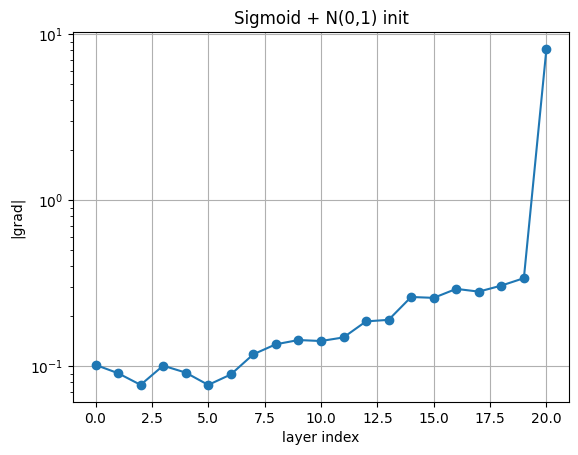

In [2]:
torch.manual_seed(0)
N_LAYERS = 20
HIDDEN = 100

layers = []
for _ in range(N_LAYERS):
    lin = nn.Linear(HIDDEN, HIDDEN)
    nn.init.normal_(lin.weight, mean=0.0, std=1.0)
    nn.init.zeros_(lin.bias)
    layers += [lin, nn.Sigmoid()]
deep_sigmoid = nn.Sequential(*layers, nn.Linear(HIDDEN, 1))

x = torch.randn(8, HIDDEN)
y = torch.zeros(8, 1)
loss = F.mse_loss(deep_sigmoid(x), y)
loss.backward()

grad_norms = []
for m in deep_sigmoid:
    if isinstance(m, nn.Linear):
        grad_norms.append(m.weight.grad.norm().item())

print(["%.2e" % g for g in grad_norms])
plt.semilogy(grad_norms, marker='o')
plt.xlabel("layer index"); plt.ylabel("|grad|"); plt.title("Sigmoid + N(0,1) init"); plt.grid(True);


**What you should see.** Gradient norms collapse exponentially toward
the bottom of the network --- many orders of magnitude. Lower layers
receive essentially zero gradient signal. This is the vanishing-gradient
problem.


![Glorot & Bengio insight](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-07.jpg)

## 1.2 Glorot and He initialization

Glorot/Xavier init uses variance $\sigma^2 = 2/(\text{fan\_in} + \text{fan\_out})$,
balancing forward and backward variance assuming a roughly linear / symmetric
saturating activation. He/Kaiming uses $\sigma^2 = 2/\text{fan\_in}$,
the doubling that compensates for ReLU zeroing half the activations.

**Your task:** apply He initialization to a fresh deep MLP with **ReLU**
activations and verify the gradient stays healthy across all 20 layers.


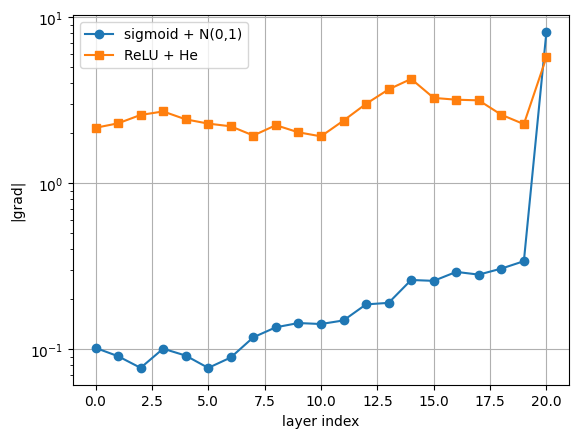

In [3]:
torch.manual_seed(0)

def make_deep_mlp(activation, init_fn):
    layers = []
    for _ in range(N_LAYERS):
        lin = nn.Linear(HIDDEN, HIDDEN)
        init_fn(lin.weight)
        nn.init.zeros_(lin.bias)
        layers += [lin, activation()]
    layers += [nn.Linear(HIDDEN, 1)]
    return nn.Sequential(*layers)

def he_init(W):
    nn.init.kaiming_normal_(W, nonlinearity='relu')

deep_relu_he = make_deep_mlp(nn.ReLU, he_init)

x = torch.randn(8, HIDDEN)
y = torch.zeros(8, 1)
loss = F.mse_loss(deep_relu_he(x), y)
loss.backward()

grad_norms_he = [m.weight.grad.norm().item() for m in deep_relu_he if isinstance(m, nn.Linear)]
plt.semilogy(grad_norms, marker='o', label="sigmoid + N(0,1)")
plt.semilogy(grad_norms_he, marker='s', label="ReLU + He")
plt.legend(); plt.xlabel("layer index"); plt.ylabel("|grad|"); plt.grid(True);


![He init sanity check](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-17.jpg)

## 1.2b Numerical sanity check

He init's promise: with $\mathcal{N}(0, 1)$ input, a `Linear(1024, 1024)`
layer followed by ReLU should preserve activation variance ($\approx 1$
in, $\approx 1$ out). Verify it.


In [4]:
torch.manual_seed(0)
W = torch.empty(1024, 1024)
nn.init.kaiming_normal_(W, nonlinearity='relu')
b = torch.zeros(1024)

x = torch.randn(8, 1024)
y = F.relu(x @ W.T + b)

print(f"Var(x) = {x.var().item():.3f}")
print(f"Var(y) = {y.var().item():.3f}")


Var(x) = 0.983
Var(y) = 0.650


![PyTorch apply()](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-21.jpg)

## 1.2c Applying init via `model.apply()`

`model.apply(fn)` does a depth-first walk of every submodule and calls
`fn` on each. Standard idiom: detect `nn.Linear`, set He init, zero the
bias.

**Your task:** write `use_he_init` and apply it to a small Sequential.


In [5]:
def use_he_init(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
        nn.init.zeros_(module.bias)

torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 20), nn.ReLU(),
    nn.Linear(20, 1),
)
model.apply(use_he_init)

for name, p in model.named_parameters():
    if 'weight' in name:
        print(f"{name}: std = {p.std().item():.3f}")


0.weight: std = 0.197
2.weight: std = 0.226
4.weight: std = 0.309


![activation comparison](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-30.jpg)

## 1.3 Activation functions

Plot ReLU, Leaky ReLU (alpha=0.01), ELU (alpha=1), GELU, and Swish/SiLU
on the range $[-4, 4]$. You should see:

- ReLU: zero for negative input, identity for positive
- Leaky ReLU: small positive slope on negative side
- ELU: smooth, asymptotes to $-\alpha$ on the negative side
- GELU and Swish: smooth, non-monotonic --- slight dip below zero before recovering


Text(0.5, 1.0, 'Modern activations')

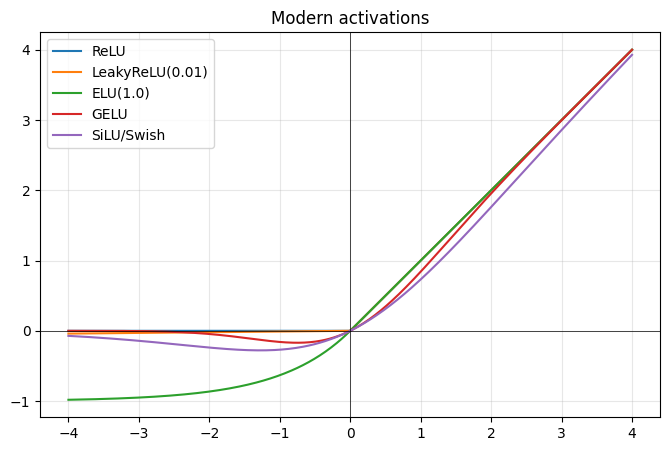

In [6]:
z = torch.linspace(-4, 4, 400)

plt.figure(figsize=(8, 5))
plt.plot(z, F.relu(z),                label="ReLU")
plt.plot(z, F.leaky_relu(z, 0.01),    label="LeakyReLU(0.01)")
plt.plot(z, F.elu(z, 1.0),            label="ELU(1.0)")
plt.plot(z, F.gelu(z),                label="GELU")
plt.plot(z, F.silu(z),                label="SiLU/Swish")

plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.legend(); plt.grid(True, alpha=0.3); plt.title("Modern activations")


![dying ReLU](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-26.jpg)

## 1.3b The dying ReLU

A neuron whose pre-activation is permanently negative outputs zero on every
input; ReLU's gradient there is exactly zero, so the neuron stops updating.

Build a single ReLU neuron with bias = $-5$ (large negative), pass random
inputs through, and confirm the gradient w.r.t. the weight is exactly zero.


In [7]:
torch.manual_seed(0)
w = torch.randn(1, 4, requires_grad=True)
b = torch.tensor(-5.0, requires_grad=True)
x = torch.randn(32, 4)

y = F.relu(x @ w.T + b)
loss = (y ** 2).mean()
loss.backward()

print("y.mean()  =", y.mean().item())
print("w.grad    =", w.grad.flatten().tolist())
print("b.grad    =", b.grad.item())


y.mean()  = 0.0
w.grad    = [0.0, 0.0, 0.0, 0.0]
b.grad    = 0.0


![batch normalization](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-32.jpg)

## 1.4 Batch Normalization by hand

Re-derive what BN does on a $[N=4, F=3]$ batch:

$$\hat{x}_{n,f} = \frac{x_{n,f} - \mu_f}{\sqrt{\sigma^2_f + \varepsilon}}, \qquad
y_{n,f} = \gamma_f \hat{x}_{n,f} + \beta_f$$

where the mean and variance are taken **across the batch axis** (one mean
per feature). Verify your manual implementation matches `nn.BatchNorm1d`.


In [8]:
X = torch.tensor([
    [1., 3., 5.],
    [2., 6., 4.],
    [3., 0., 6.],
    [4., 3., 1.],
])

eps = 1e-5
mu  = X.mean(dim=0, keepdim=True)
var = X.var(dim=0, keepdim=True, unbiased=False)
xhat_manual = (X - mu) / torch.sqrt(var + eps)

bn = nn.BatchNorm1d(3, eps=eps, affine=False)
bn.train()
xhat_bn = bn(X)

print("manual:\n", xhat_manual)
print("\nBatchNorm1d:\n", xhat_bn)
print("\nmax abs diff:", (xhat_manual - xhat_bn).abs().max().item())


manual:
 tensor([[-1.3416,  0.0000,  0.5345],
        [-0.4472,  1.4142,  0.0000],
        [ 0.4472, -1.4142,  1.0690],
        [ 1.3416,  0.0000, -1.6036]])

BatchNorm1d:
 tensor([[-1.3416e+00, -2.9802e-08,  5.3452e-01],
        [-4.4721e-01,  1.4142e+00,  0.0000e+00],
        [ 4.4721e-01, -1.4142e+00,  1.0690e+00],
        [ 1.3416e+00, -2.9802e-08, -1.6036e+00]])

max abs diff: 1.1920928955078125e-07


![BN train vs eval mode](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-41.jpg)

## 1.4b BN train mode vs eval mode

In training mode BN uses the **current batch's** mean and variance, and
updates a running mean/var for inference. In eval mode it freezes those
running statistics.

**Your task:** train a tiny BN layer on random batches for a few steps,
then switch to eval mode. Compare its output on a single test point in
both modes --- they should differ.


In [9]:
torch.manual_seed(0)
bn = nn.BatchNorm1d(3, momentum=0.1)

for _ in range(20):
    bn.train()
    _ = bn(torch.randn(64, 3) * 5 + 2)

x_test = torch.tensor([[2., 2., 2.]])

bn.train()
out_train = bn(torch.cat([x_test, torch.randn(63, 3) * 5 + 2]))[:1]

bn.eval()
out_eval = bn(x_test)

print("running mean:", bn.running_mean.tolist())
print("running var :", bn.running_var.tolist())
print("output train (single test point in a fresh batch):", out_train.flatten().tolist())
print("output eval :", out_eval.flatten().tolist())


running mean: [1.68278169631958, 1.6310114860534668, 1.7469639778137207]
running var : [22.064043045043945, 21.77195167541504, 20.315296173095703]
output train (single test point in a fresh batch): [0.3051961660385132, 0.03209373354911804, 0.043080806732177734]
output eval : [0.06753292679786682, 0.0790795385837555, 0.05613976716995239]


![LayerNorm](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-48.jpg)

## 1.5 Layer Normalization

LayerNorm normalizes across the **feature dimension** of each example:
one mean and variance *per row*, not per column. This makes it
batch-size-independent (works the same on a batch of 1 or 1000) and
identical between train and eval modes.

**Your task:** compute LN by hand on the same matrix and compare with
`nn.LayerNorm`.


In [10]:
eps = 1e-5
mu_ln  = X.mean(dim=1, keepdim=True)
var_ln = X.var(dim=1, keepdim=True, unbiased=False)
xhat_ln_manual = (X - mu_ln) / torch.sqrt(var_ln + eps)

ln = nn.LayerNorm(3, eps=eps, elementwise_affine=False)
xhat_ln = ln(X)

print("manual LN:\n", xhat_ln_manual)
print("\nnn.LayerNorm:\n", xhat_ln)
print("\nmax abs diff:", (xhat_ln_manual - xhat_ln).abs().max().item())


manual LN:
 tensor([[-1.2247,  0.0000,  1.2247],
        [-1.2247,  1.2247,  0.0000],
        [ 0.0000, -1.2247,  1.2247],
        [ 1.0690,  0.2673, -1.3363]])

nn.LayerNorm:
 tensor([[-1.2247,  0.0000,  1.2247],
        [-1.2247,  1.2247,  0.0000],
        [ 0.0000, -1.2247,  1.2247],
        [ 1.0690,  0.2673, -1.3363]])

max abs diff: 1.1920928955078125e-07


![gradient clipping](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-a-53.jpg)

## 1.6 Gradient clipping

Synthetically blow up a gradient (multiply the loss by a huge factor) and
verify that `clip_grad_norm_` rescales the global gradient L2 norm to
`max_norm`.


In [11]:
torch.manual_seed(0)
m = nn.Linear(50, 50)
x = torch.randn(8, 50)
loss = (m(x) ** 2).sum() * 1e6
loss.backward()

pre_norm = sum(p.grad.norm() ** 2 for p in m.parameters()).sqrt().item()
print(f"pre-clip global norm: {pre_norm:.2e}")

clipped = nn.utils.clip_grad_norm_(m.parameters(), max_norm=1.0)
post_norm = sum(p.grad.norm() ** 2 for p in m.parameters()).sqrt().item()
print(f"post-clip global norm: {post_norm:.2e}  (max_norm = 1.0)")
print(f"clipped (returned pre-clip norm): {clipped:.2e}")


pre-clip global norm: 1.64e+08
post-clip global norm: 1.00e+00  (max_norm = 1.0)
clipped (returned pre-clip norm): 1.64e+08


---
# Part 2 --- Faster Training & Generalization

Optimizers, learning-rate schedules, regularization.


![narrow valley](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-08.jpg)

## 2.1 Momentum on a narrow valley

Loss surface $f(x, y) = x^2 + 100 y^2$ --- a long narrow ravine. Plain
SGD oscillates wildly across the $y$-axis (gradient is $200y$ in $y$ vs
$2x$ in $x$). Momentum smooths the oscillations.

**Your task:** run plain GD vs GD-with-momentum from the same starting
point and plot the trajectories.


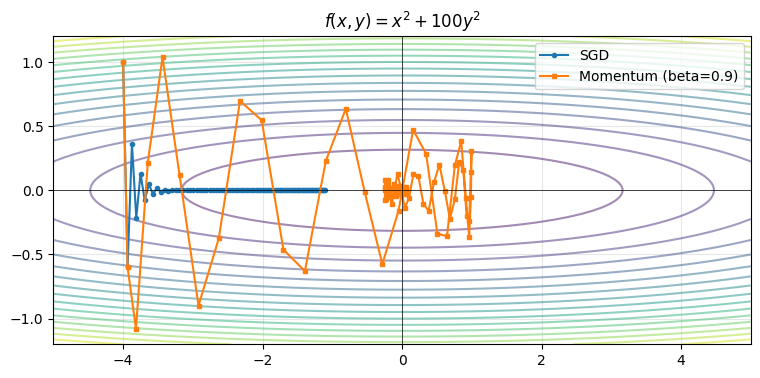

In [12]:
def grad_f(p):
    x, y = p
    return np.array([2 * x, 200 * y])

def run_gd(start, lr, n_steps, beta=0.0):
    p = np.array(start, dtype=float)
    m = np.zeros_like(p)
    traj = [p.copy()]
    for _ in range(n_steps):
        g = grad_f(p)
        m = beta * m + g
        p = p - lr * m
        traj.append(p.copy())
    return np.array(traj)

start = (-4.0, 1.0)
lr = 0.008
T_sgd = run_gd(start, lr, 80, beta=0.0)
T_mom = run_gd(start, lr, 80, beta=0.9)

xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-1.2, 1.2, 100))
ff = xx**2 + 100 * yy**2
plt.figure(figsize=(9, 4))
plt.contour(xx, yy, ff, levels=20, cmap='viridis', alpha=0.5)
plt.plot(T_sgd[:, 0], T_sgd[:, 1], 'o-', ms=3, label='SGD')
plt.plot(T_mom[:, 0], T_mom[:, 1], 's-', ms=3, label='Momentum (beta=0.9)')
plt.axhline(0, color='black', lw=0.5); plt.axvline(0, color='black', lw=0.5)
plt.legend(); plt.title("$f(x, y) = x^2 + 100 y^2$"); plt.grid(True, alpha=0.3);


## Loading FashionMNIST

The remaining sections use FashionMNIST. We split off a small validation
fold so we can plot training curves cleanly.


In [13]:
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

DATA_DIR = "./data"
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,)),  # FashionMNIST mean/std
])

full_train = torchvision.datasets.FashionMNIST(DATA_DIR, train=True,  download=True, transform=tfm)
test_set   = torchvision.datasets.FashionMNIST(DATA_DIR, train=False, download=True, transform=tfm)

torch.manual_seed(0)
train_set, valid_set = random_split(full_train, [55_000, 5_000])
train_loader = DataLoader(train_set, batch_size=256, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_set, batch_size=512, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=512, shuffle=False, num_workers=0)

print(len(train_set), "train,", len(valid_set), "valid,", len(test_set), "test")


100%|██████████| 26.4M/26.4M [00:01<00:00, 16.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 235kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.39MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.2MB/s]

55000 train, 5000 valid, 10000 test


In [14]:
def make_classifier(use_bn=False, dropout=0.0):
    layers = [nn.Flatten()]
    in_dim = 28 * 28
    for hidden in (300, 100):
        layers.append(nn.Linear(in_dim, hidden))
        if use_bn:
            layers.append(nn.BatchNorm1d(hidden))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        in_dim = hidden
    layers.append(nn.Linear(in_dim, 10))
    return nn.Sequential(*layers)


@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    n_correct = n_total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(dim=1)
        n_correct += (pred == y).sum().item()
        n_total   += y.size(0)
    return n_correct / n_total


def train_one_epoch(model, optimizer, loader, scheduler=None, per_batch_step=False):
    model.train()
    losses = []
    crit = nn.CrossEntropyLoss()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = crit(model(x), y)
        loss.backward()
        optimizer.step()
        if per_batch_step and scheduler is not None:
            scheduler.step()
        losses.append(loss.item())
    return float(np.mean(losses))


![Adam in PyTorch](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-19.jpg)

## 2.2 Optimizer race: SGD vs Momentum vs Adam

Train the same MLP for 5 epochs with three optimizers. Adam usually wins
on convergence speed; SGD+momentum can match or beat it given enough
tuning.


SGD lr=0.05
  SGD  epoch 1: train_loss = 0.8718
  SGD  epoch 2: train_loss = 0.5058
  SGD  epoch 3: train_loss = 0.4447
  SGD  epoch 4: train_loss = 0.4124
  SGD  epoch 5: train_loss = 0.3891
  SGD  val_acc = 0.8540

SGD + Momentum 0.9
  Momentum  epoch 1: train_loss = 0.5947
  Momentum  epoch 2: train_loss = 0.3709
  Momentum  epoch 3: train_loss = 0.3246
  Momentum  epoch 4: train_loss = 0.3003
  Momentum  epoch 5: train_loss = 0.2774
  Momentum  val_acc = 0.8844

Adam lr=1e-3
  Adam  epoch 1: train_loss = 0.5411
  Adam  epoch 2: train_loss = 0.3702
  Adam  epoch 3: train_loss = 0.3282
  Adam  epoch 4: train_loss = 0.2981
  Adam  epoch 5: train_loss = 0.2798
  Adam  val_acc = 0.8832


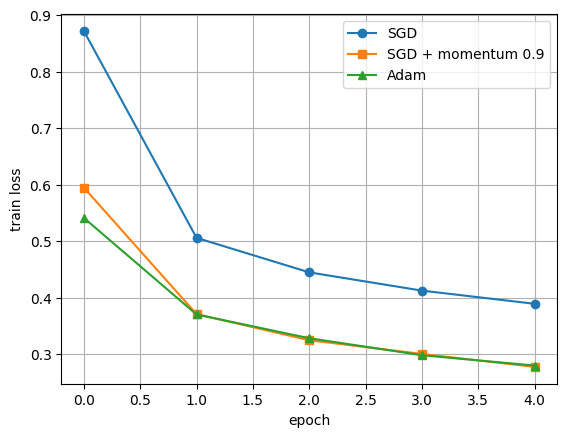

In [15]:
def fresh_model(seed=0, **kwargs):
    torch.manual_seed(seed)
    return make_classifier(**kwargs).to(device)

def race(make_opt, label, n_epochs=5):
    model = fresh_model()
    opt = make_opt(model.parameters())
    losses = []
    for ep in range(n_epochs):
        losses.append(train_one_epoch(model, opt, train_loader))
        print(f"  {label}  epoch {ep+1}: train_loss = {losses[-1]:.4f}")
    val = accuracy(model, valid_loader)
    print(f"  {label}  val_acc = {val:.4f}")
    return losses

print("SGD lr=0.05")
hist_sgd = race(lambda p: torch.optim.SGD(p, lr=0.05), "SGD")
print("\nSGD + Momentum 0.9")
hist_mom = race(lambda p: torch.optim.SGD(p, lr=0.05, momentum=0.9), "Momentum")
print("\nAdam lr=1e-3")
hist_adam = race(lambda p: torch.optim.Adam(p, lr=1e-3), "Adam")

plt.plot(hist_sgd,  marker='o', label='SGD')
plt.plot(hist_mom,  marker='s', label='SGD + momentum 0.9')
plt.plot(hist_adam, marker='^', label='Adam')
plt.legend(); plt.xlabel("epoch"); plt.ylabel("train loss"); plt.grid(True);


![schedule comparison](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-30.jpg)

## 2.3 LR schedules: visualize the curves

Before plugging a schedule into a training run, visualize what each one
does to the LR over time. We'll compare four:

- `ExponentialLR(gamma=0.9)` --- multiplies LR by 0.9 every epoch
- `CosineAnnealingLR(T_max=20)` --- half-cosine from `lr` to `eta_min`
- `CosineAnnealingWarmRestarts(T_0=5, T_mult=2)` --- cosine cycles
- `OneCycleLR(max_lr, total_steps)` --- one big triangular cycle, *per batch*


/tmp/ipykernel_5007/690674724.py:12: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


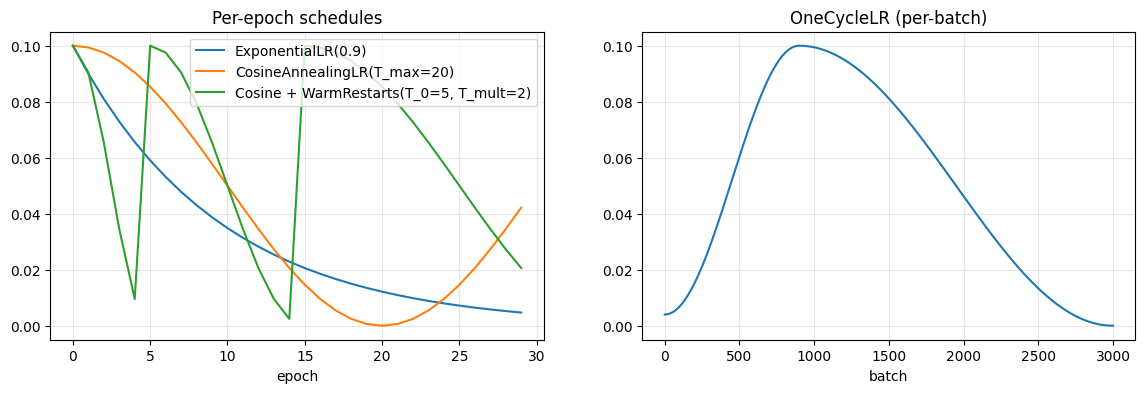

In [16]:
from torch.optim.lr_scheduler import (
    ExponentialLR, CosineAnnealingLR, CosineAnnealingWarmRestarts, OneCycleLR,
)

def lr_curve(make_sched, n_steps, lr0=0.1):
    p = nn.Parameter(torch.zeros(1))
    opt = torch.optim.SGD([p], lr=lr0)
    sched = make_sched(opt)
    history = []
    for _ in range(n_steps):
        history.append(opt.param_groups[0]['lr'])
        sched.step()
    return history

n_epochs = 30
exp_lr = lr_curve(lambda o: ExponentialLR(o, gamma=0.9), n_epochs)
cos_lr = lr_curve(lambda o: CosineAnnealingLR(o, T_max=20), n_epochs)
wr_lr  = lr_curve(lambda o: CosineAnnealingWarmRestarts(o, T_0=5, T_mult=2), n_epochs)

batches_per_epoch = 100
oc_lr = lr_curve(
    lambda o: OneCycleLR(o, max_lr=0.1, total_steps=n_epochs * batches_per_epoch),
    n_epochs * batches_per_epoch,
    lr0=0.1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(exp_lr, label='ExponentialLR(0.9)')
axes[0].plot(cos_lr, label='CosineAnnealingLR(T_max=20)')
axes[0].plot(wr_lr,  label='Cosine + WarmRestarts(T_0=5, T_mult=2)')
axes[0].set_xlabel("epoch"); axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_title("Per-epoch schedules")

axes[1].plot(oc_lr)
axes[1].set_xlabel("batch"); axes[1].set_title("OneCycleLR (per-batch)"); axes[1].grid(True, alpha=0.3);


![PyTorch dance](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-31.jpg)

## 2.3b Plug a schedule into training

Train the classifier for 5 epochs with `CosineAnnealingLR`. Note that
most schedulers step **once per epoch** (after the inner batch loop);
`OneCycleLR` is the exception and steps per batch.


In [17]:
torch.manual_seed(0)
model = make_classifier().to(device)
opt = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5, eta_min=1e-4)

losses, lrs = [], []
for ep in range(5):
    losses.append(train_one_epoch(model, opt, train_loader))
    lrs.append(opt.param_groups[0]['lr'])
    sched.step()
    print(f"epoch {ep+1}: train_loss={losses[-1]:.4f}  lr={lrs[-1]:.4f}")

print("val_acc:", accuracy(model, valid_loader))


epoch 1: train_loss=0.5947  lr=0.0500
epoch 2: train_loss=0.3679  lr=0.0452
epoch 3: train_loss=0.3157  lr=0.0328
epoch 4: train_loss=0.2757  lr=0.0173
epoch 5: train_loss=0.2538  lr=0.0049
val_acc: 0.89


![L2 weight decay](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-33.jpg)

## 2.4 L2 regularization (weight decay)

PyTorch optimizers expose `weight_decay`. With SGD this is mathematically
equivalent to adding $\tfrac{1}{2}\lambda \|\theta\|^2$ to the
loss --- weights shrink toward zero each step.

**Your task:** train two models, one with `weight_decay=0` and one with
`weight_decay=1e-3`. Compare their average weight magnitude at the end.


In [18]:
def avg_abs_weight(model):
    total = sum(p.abs().sum() for p in model.parameters() if p.requires_grad)
    count = sum(p.numel()       for p in model.parameters() if p.requires_grad)
    return (total / count).item()

torch.manual_seed(0)
m_no = make_classifier().to(device)
o_no = torch.optim.SGD(m_no.parameters(), lr=0.05, momentum=0.9, weight_decay=0.0)

torch.manual_seed(0)
m_wd = make_classifier().to(device)
o_wd = torch.optim.SGD(m_wd.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-3)

for ep in range(3):
    train_one_epoch(m_no, o_no, train_loader)
    train_one_epoch(m_wd, o_wd, train_loader)

print(f"avg |w| no decay   : {avg_abs_weight(m_no):.4f}")
print(f"avg |w| weight_decay=1e-3: {avg_abs_weight(m_wd):.4f}")


avg |w| no decay   : 0.0234
avg |w| weight_decay=1e-3: 0.0182


![dropout in PyTorch](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-40.jpg)

## 2.5 Dropout: behaviour in train vs eval mode

`nn.Dropout(p)` zeros each entry independently with probability $p$ and
**rescales** the survivors by $1/(1-p)$ in training mode. In eval mode
it's an identity.

**Your task:** confirm both behaviors numerically on a fixed input.


In [19]:
torch.manual_seed(0)
drop = nn.Dropout(p=0.5)

x = torch.ones(1, 8)

drop.train()
out_train = drop(x)

drop.eval()
out_eval = drop(x)

print("train (50% dropout, scaled by 2):", out_train.flatten().tolist())
print("eval  (identity)                :", out_eval.flatten().tolist())


train (50% dropout, scaled by 2): [0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 2.0, 2.0]
eval  (identity)                : [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


## 2.5b Train a classifier with dropout

Build the same MLP with `dropout=0.2` on each hidden layer and train for
3 epochs. Compare validation accuracy to the baseline (no dropout) you
trained earlier.


In [20]:
torch.manual_seed(0)
m_drop = make_classifier(dropout=0.2).to(device)
o_drop = torch.optim.Adam(m_drop.parameters(), lr=1e-3)

for ep in range(3):
    loss = train_one_epoch(m_drop, o_drop, train_loader)
    val = accuracy(m_drop, valid_loader)
    print(f"epoch {ep+1}: train_loss={loss:.4f}  val_acc={val:.4f}")


epoch 1: train_loss=0.5860  val_acc=0.8464
epoch 2: train_loss=0.4007  val_acc=0.8668
epoch 3: train_loss=0.3637  val_acc=0.8762


![MC dropout](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-41.jpg)

## 2.6 Monte Carlo Dropout

Keep dropout *on* at inference and run the same input through the network
$K$ times. The mean of the $K$ softmax outputs is a slightly better
prediction; the standard deviation is a (cheap) uncertainty estimate.

**Your task:** call `model.train()` to keep dropout active, run $K = 30$
forward passes on a single test image, and report the mean and std of the
predicted probability for the most-likely class.


In [21]:
K = 30
m_drop.train()
x_one, y_one = test_set[0]
x_one = x_one.unsqueeze(0).to(device)

with torch.no_grad():
    samples = torch.stack([
        F.softmax(m_drop(x_one), dim=1)
        for _ in range(K)
    ])

probs = samples[:, 0]
mean_p = probs.mean(dim=0)
std_p  = probs.std(dim=0)

c = mean_p.argmax().item()
print(f"true label: {y_one}")
print(f"top class : {c}")
print(f"  mean p  = {mean_p[c].item():.3f}")
print(f"  std  p  = {std_p[c].item():.3f}  (uncertainty)")


true label: 9
top class : 9
  mean p  = 0.743
  std  p  = 0.181  (uncertainty)


![max-norm regularization](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-43.jpg)

## 2.7 Max-norm regularization

For each weight row $w$, enforce $\|w\|_2 \le r$ by projecting back
onto the ball after every optimizer step:

```
w <- w * min(1, r / ||w||_2)
```

**Your task:** write `apply_max_norm(model, max_norm)` that walks every
non-bias parameter and projects each row.


In [22]:
def apply_max_norm(model, max_norm=2.0, eps=1e-8, dim=1):
    with torch.no_grad():
        for n, p in model.named_parameters():
            if "bias" in n:
                continue
            actual = p.norm(p=2, dim=dim, keepdim=True)
            target = torch.clamp(actual, 0, max_norm)
            p.mul_(target / (eps + actual))

torch.manual_seed(0)
m = nn.Linear(10, 4)
with torch.no_grad():
    m.weight.mul_(50.0)
print("before:", m.weight.norm(p=2, dim=1).tolist())

apply_max_norm(m, max_norm=2.0)

print("after :", m.weight.norm(p=2, dim=1).tolist())


before: [24.668052673339844, 26.54302215576172, 30.007673263549805, 33.20169448852539]
after : [2.0, 2.0, 2.0, 1.9999998807907104]


![full default config](https://raw.githubusercontent.com/zhiyunli/cpsc5610-labs/main/week5/slides/slide-b-48.jpg)

## 2.8 Putting it all together

Train a final FashionMNIST classifier using the recommended defaults from
the slides:

- He init for the Linear layers (handled implicitly: PyTorch's default
  `kaiming_uniform_` matches ReLU)
- ReLU activations
- BatchNorm between Linear and ReLU
- AdamW optimizer with `weight_decay=1e-2`
- CosineAnnealingLR over 5 epochs
- Dropout 0.2 on hidden layers

Track training loss and validation accuracy each epoch, and report final
test accuracy.


In [23]:
def make_final_classifier(dropout=0.2):
    layers = [nn.Flatten()]
    in_dim = 28 * 28
    for hidden in (300, 100):
        layers += [
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
        in_dim = hidden
    layers.append(nn.Linear(in_dim, 10))
    return nn.Sequential(*layers)


torch.manual_seed(0)
model = make_final_classifier().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=5, eta_min=1e-5)

n_epochs = 5
for ep in range(n_epochs):
    loss = train_one_epoch(model, opt, train_loader)
    sched.step()
    val = accuracy(model, valid_loader)
    print(f"epoch {ep+1}: loss={loss:.4f}  val_acc={val:.4f}  lr={opt.param_groups[0]['lr']:.4f}")

print("\nfinal test accuracy:", accuracy(model, test_loader))


epoch 1: loss=0.5616  val_acc=0.8506  lr=0.0009
epoch 2: loss=0.3760  val_acc=0.8766  lr=0.0007
epoch 3: loss=0.3341  val_acc=0.8878  lr=0.0004
epoch 4: loss=0.2963  val_acc=0.8898  lr=0.0001
epoch 5: loss=0.2725  val_acc=0.8922  lr=0.0000

final test accuracy: 0.8869


---
## Wrap-up

You now have hands-on experience with every Week 5 technique:

- Spotted the vanishing gradient signature of `sigmoid + N(0,1)` and fixed it with He init + ReLU.
- Verified the four-step BatchNorm computation against `nn.BatchNorm1d` and observed train vs eval differences.
- Compared LayerNorm's per-example normalization against BatchNorm's per-feature normalization on the same matrix.
- Caught and clipped an exploding gradient.
- Watched momentum smooth out the oscillations of plain SGD on a narrow valley, and raced SGD / Momentum / Adam on FashionMNIST.
- Visualized four LR schedules and trained a model with cosine annealing.
- Compared weight-decay vs no decay, observed dropout's train/eval asymmetry, and used MC dropout for a free uncertainty estimate.
- Implemented max-norm projection from scratch.
- Combined the recommended defaults (BN + ReLU + dropout + AdamW + cosine LR) into a final classifier.
